### Modeling

This notebook trains and evaluates a fraud detection model using the processed data from the cleaning/preprocessing notebook.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)


### Load Processed Data

In [5]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_val = pd.read_csv("../data/processed/X_val.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_val = pd.read_csv("../data/processed/y_val.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()


### Shape check

In [6]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)


X_train: (40749, 14)
X_val: (8732, 14)
X_test: (8732, 14)


### Training Random Forest

In [7]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### Generate validation predictions

In [8]:
y_val_pred = rf.predict(X_val)
y_val_proba = rf.predict_proba(X_val)[:, 1]


### Evaluation

In [9]:
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1 Score:", f1_score(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_proba))

print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred))


Precision: 0.9991863303498779
Recall: 0.9967532467532467
F1 Score: 0.9979683055668428
ROC-AUC: 0.9990117424242424

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7500
           1       1.00      1.00      1.00      1232

    accuracy                           1.00      8732
   macro avg       1.00      1.00      1.00      8732
weighted avg       1.00      1.00      1.00      8732



### Confusion Matrix

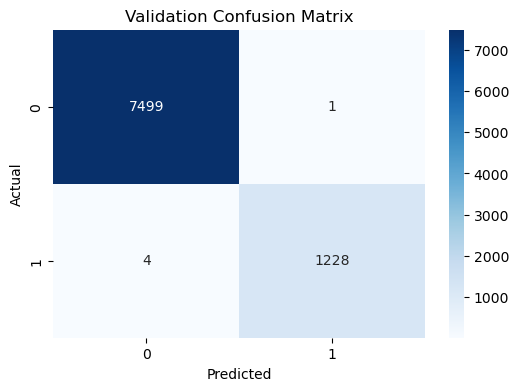

In [10]:
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### ROC curve

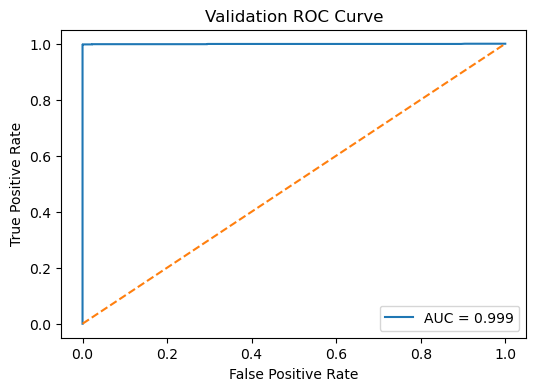

In [11]:
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_val, y_val_proba):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve")
plt.legend()
plt.show()


### Feature importance

In [12]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(10)


,feature,importance
7,orig_balance_error,0.321693
9,orig_error_flag,0.260037
3,newbalanceOrig,0.101372
2,oldbalanceOrg,0.087890
5,newbalanceDest,0.066906
8,dest_balance_error,0.034714
0,step,0.030987
1,amount,0.025609
4,oldbalanceDest,0.024168
10,dest_error_flag,0.016779


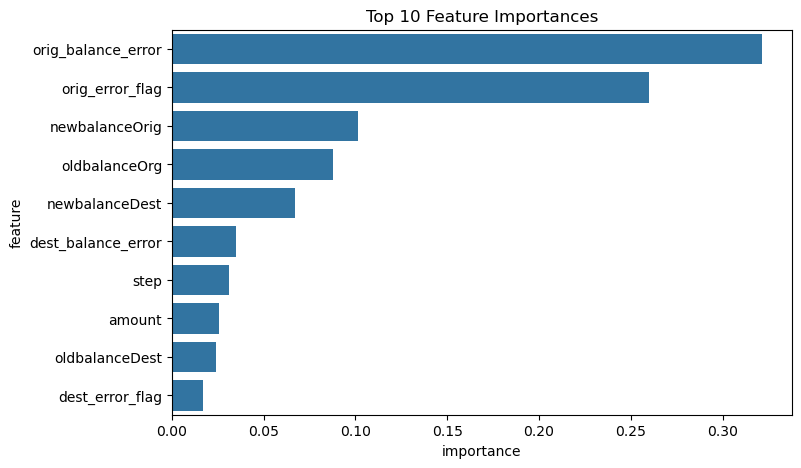

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance.head(10), x="importance", y="feature")
plt.title("Top 10 Feature Importances")
plt.show()


### Second model
Increasing the complexity of the second model to see if performance improves or largely stays the same.

In [14]:
rf2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf2.fit(X_train, y_train)

y_val_pred2 = rf2.predict(X_val)
y_val_proba2 = rf2.predict_proba(X_val)[:, 1]

print("Precision:", precision_score(y_val, y_val_pred2))
print("Recall:", recall_score(y_val, y_val_pred2))
print("F1 Score:", f1_score(y_val, y_val_pred2))
print("ROC-AUC:", roc_auc_score(y_val, y_val_proba2))


Precision: 0.9991863303498779
Recall: 0.9967532467532467
F1 Score: 0.9979683055668428
ROC-AUC: 0.998929274891775


In [15]:
best_model = rf

y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

print("Test Precision:", precision_score(y_test, y_test_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))
print("Test F1 Score:", f1_score(y_test, y_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_proba))

print("\nTest Classification Report:\n")
print(classification_report(y_test, y_test_pred))


Test Precision: 1.0
Test Recall: 0.9983766233766234
Test F1 Score: 0.9991876523151909
Test ROC-AUC: 0.9992923160173162

Test Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7500
           1       1.00      1.00      1.00      1232

    accuracy                           1.00      8732
   macro avg       1.00      1.00      1.00      8732
weighted avg       1.00      1.00      1.00      8732



### Conclusions and thoughts

The first Random Forest model was selected as the final model because it performed nearly identically to the second model while having less complexity. The model has very strong fraud-detection performance with especially high precision and recall. Feature importance show balance-related variables were the most influential predictors. This is consistent with patterns observed during EDA